In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from conus_biomass import dir_info
from conus_biomass.make_figures import maps

In [2]:
df_all_westwide = pd.read_csv("OurStudy_western_stocks.csv")
western_stocks=pd.read_csv("USFS_western_stocks.csv")

In [3]:
western_stocks=western_stocks.rename(columns={'Unnamed: 0':'year',
                              '0':'live_biomass_MMT'})

In [4]:
biomass_mean_west = df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).median()
biomass_min_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.975)
)

biomass_mean_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).median()
)
biomass_min_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.975)
)

# a) absolute biomass stock

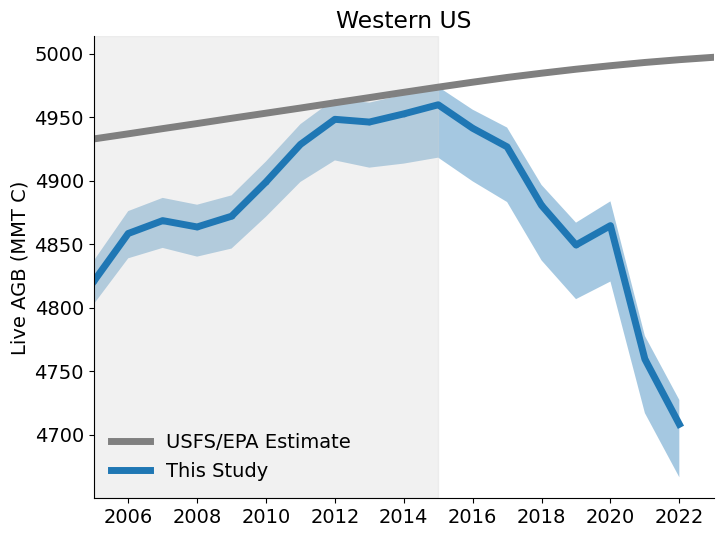

In [5]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(8, 6))

plt.plot(western_stocks['year'], western_stocks['live_biomass_MMT'], "-", linewidth=5, color="gray", label="USFS/EPA Estimate")

plt.plot(
    biomass_mean_west.index,
    (np.array(biomass_mean_west)),
    ".-",
    linewidth=5,
    color="C0",
    label="This Study",
)
plt.fill_between(
    biomass_min_west.index,
    (np.array(biomass_min_west)),
    (np.array(biomass_max_west)),
    color="C0",
    alpha=0.4,
    edgecolor=None,
)

plt.title("Western US")
plt.ylabel("Live AGB (MMT C)")
ax.spines[["right", "top"]].set_visible(False)
plt.legend(frameon=False)
ax.set_xlim([2005, 2023])
plt.axvspan(2005, 2015, color="lightgray", alpha=0.3)

# b) live biomass changes

In [6]:
slope = xr.open_zarr(dir_info.dir_processed + "data_on_ref_grid/1000m/aspect.zarr")
crs = slope["spatial_ref"].crs_wkt

In [7]:
inputs = xr.open_dataset(dir_info.dir_processed + "data_on_ref_grid/1000m/all_variables.nc")

In [8]:
dir_data = dir_info.dir_model_output[:-1] + "_processed/"

In [9]:
slope = xr.open_zarr(dir_info.dir_processed + "data_on_ref_grid/1000m/aspect.zarr")
crs = slope["spatial_ref"].crs_wkt
western_states = maps.SHP_WESTERN.to_crs(crs)

In [10]:
def get_filtered_output(
    year,
    fdir=dir_data,
    ftype="nc",
    vartype="predicted_biomass_filtered_",
):
    fname = fdir + vartype + str(year)
    if ftype == "zarr":
        ds = xr.open_zarr(fname + ".zarr")
    elif ftype == "nc":
        ds = xr.load_dataset(fname + "_0000.nc")
    return ds


ds_end = get_filtered_output(year=2022)
ds_start = get_filtered_output(year=2005)
delta_biomass = ds_end["predicted_biomass"] - ds_start["predicted_biomass"]

In [11]:
inputs = xr.open_dataset(dir_info.dir_processed + "data_on_ref_grid/1000m/all_variables.nc")
inputs = inputs.rio.write_crs(crs)

In [12]:
burned = inputs["years_after_fire"].sel(year=2022) <= 17

In [13]:
burned_clipped = burned.rio.clip(western_states.geometry)

In [14]:
biomass_start_clipped = (
    ds_start["predicted_biomass"].rio.write_crs(crs).rio.clip(western_states.geometry)
)

In [15]:
delta_biomass = delta_biomass.rio.write_crs(crs)

In [16]:
delta_biomass_clipped = delta_biomass.rio.clip(western_states.geometry)

<Axes: title={'center': 'Change in Live Aboveground Biomass from 2005-2020'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>

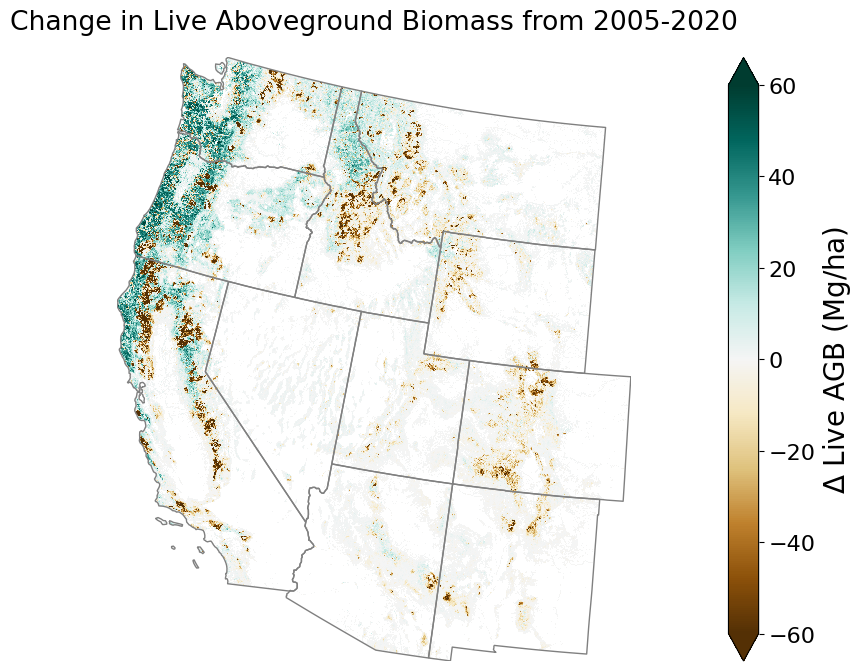

In [17]:
maps.plot_map(
    delta_biomass_clipped,  # .mean(),
    shp=western_states,
    latlon=False,
    title="Change in Live Aboveground Biomass from 2005-2020",
    cbar_label=r"$\Delta$ Live AGB (Mg/ha)",
    cmap=plt.cm.BrBG,
    clims=[-60, 60],
    savefig=None,
)
# plt.savefig('Figure2.pdf')

# Combined

In [ ]:
fig = plt.figure(figsize=(24, 10))
font_settings = {
    "font.size": 24,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "legend.fontsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
}
plt.rcParams.update(font_settings)


# Create axes with width ratios: left panel smaller, right panel bigger
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.05)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

# Left plot - time series
ax0 = axes[0]
ax0.plot(western_stocks['year'], western_stocks['live_biomass_MMT'], "-", linewidth=5, color="gray", label="USFS/EPA Estimate")

ax0.plot(
    biomass_mean_west.index,
    (np.array(biomass_mean_west)),
    ".-",
    linewidth=5,
    color="C0",
    label="This Study",
)
ax0.fill_between(
    biomass_min_west.index,
    (np.array(biomass_min_west)),
    (np.array(biomass_max_west)),
    color="C0",
    alpha=0.4,
    edgecolor=None,
)

ax0.set_ylabel("Live AGB (MMT C)")
ax0.spines[["right", "top"]].set_visible(False)
ax0.legend(frameon=False)
ax0.set_xlim([2005, 2023])
ax0.axvspan(2005, 2015, color="lightgray", alpha=0.3)

ax0.text(
    -0.12,
    1.05,
    "a",
    transform=ax0.transAxes,
    fontsize=font_settings["font.size"],
    fontweight="bold",
    va="top",
)

ax1 = axes[1]
maps.plot_map(
    delta_biomass_clipped,  # .mean(),
    shp=western_states,
    latlon=False,
    title=None,
    cbar_label=r"$\Delta$ Live AGB (Mg/ha)",
    cmap=plt.cm.BrBG,
    clims=[-60, 60],
    savefig=None,
    ax=ax1
)
ax1.text(
    -0.05,
    1.05,
    "b",
    transform=ax1.transAxes,
    fontsize=font_settings["font.size"],
    fontweight="bold",
    va="top",
)
#fig.suptitle("", y=0.98) # invisible anchor line 
#ax0.set_title("Western US", y=1.07)
#ax1.set_title("Change in Live Aboveground Biomass from 2005–2022", y=1.07)

fig.subplots_adjust(left=0.05, right=0.92, top=0.92, bottom=0.08, wspace=-0.1)
fig.savefig(dir_info.dir_figures + "Figure2.jpg", bbox_inches="tight", dpi=300)

/data/homezvol3/czarakas/conus-biomass/src/conus_biomass/make_figures/maps.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/data/homezvol3/czarakas/conus-biomass/src/conus_biomass/make_figures/maps.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
